# W4D1: Model Evaluation Metrics

## Objective

Evaluate a classification model using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

Also understand:
- K-Fold Cross-Validation
- Stratified K-Fold Cross-Validation
- Learning Curves
- Overfitting and Underfitting
- MLflow experiment tracking

## 1. Import Required Libraries

We import the libraries required for data generation, model training, evaluation metrics, cross-validation, visualization, and experiment tracking.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    learning_curve
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

import mlflow
import mlflow.sklearn

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Create a Classification Dataset

A synthetic binary classification dataset is created using `make_classification`.

The dataset contains 1,000 samples and 10 features.

In [3]:
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=2,
    random_state=42
)

print("Dataset created successfully.")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Class distribution:")
print(pd.Series(y).value_counts())

Dataset created successfully.
Number of samples: 1000
Number of features: 10
Class distribution:
1    502
0    498
Name: count, dtype: int64


## 3. Train-Test Split

The dataset is divided into training and testing sets.

We use stratification so that both sets maintain a similar class distribution.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train/Test split completed.")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Train/Test split completed.
Training samples: 800
Testing samples: 200


## 4. Build the Classification Pipeline

A pipeline is used to standardize the features and train a Logistic Regression classifier.

Using a pipeline helps prevent data leakage during model evaluation.

In [5]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(random_state=42))
])

model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


## 5. Generate Predictions

The trained model is used to predict the test-set classes and probabilities.

The probabilities are required for calculating ROC-AUC.

In [6]:
y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("First 10 predictions:", y_pred[:10])

Predictions generated successfully.
First 10 predictions: [0 1 0 0 1 1 0 0 1 0]


## 6. Model Evaluation Metrics

We evaluate the model using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

These metrics provide a more complete understanding of classification performance than accuracy alone.

In [7]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_probability)

print("Model Evaluation Metrics")
print("-" * 35)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

Model Evaluation Metrics
-----------------------------------
Accuracy : 0.8200
Precision: 0.7909
Recall   : 0.8700
F1 Score : 0.8286
ROC-AUC  : 0.8797


## 7. Classification Report

The classification report provides precision, recall, F1-score, and support for each class.

In [8]:
print("Classification Report")
print("-" * 50)
print(classification_report(y_test, y_pred, zero_division=0))

Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.77      0.81       100
           1       0.79      0.87      0.83       100

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200



## 8. Confusion Matrix

The confusion matrix shows the number of true positives, true negatives, false positives, and false negatives.

In [9]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[77 23]
 [13 87]]


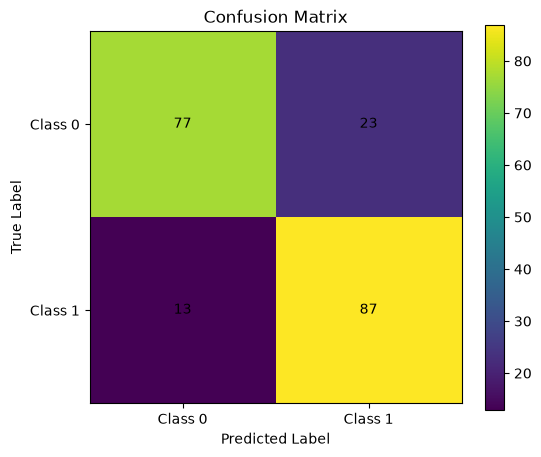

In [10]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## 9. ROC Curve and ROC-AUC

The ROC curve shows the relationship between the True Positive Rate and False Positive Rate at different classification thresholds.

ROC-AUC measures how well the model separates the two classes.

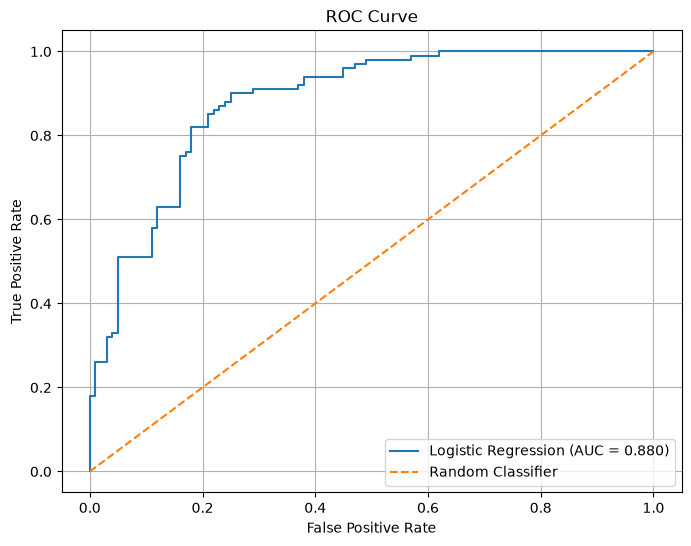

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_probability)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.show()

## 10. K-Fold Cross-Validation

K-Fold Cross-Validation divides the dataset into multiple folds.

The model is trained and evaluated multiple times so that performance is not dependent on a single train-test split.

In [12]:
kfold_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("5-Fold Cross-Validation Results")
print("-" * 40)

for i, score in enumerate(kfold_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"Mean CV Accuracy: {kfold_scores.mean():.4f}")
print(f"Std CV Accuracy : {kfold_scores.std():.4f}")

5-Fold Cross-Validation Results
----------------------------------------
Fold 1: 0.8250
Fold 2: 0.8500
Fold 3: 0.8050
Fold 4: 0.7950
Fold 5: 0.8350
Mean CV Accuracy: 0.8220
Std CV Accuracy : 0.0199


## 11. Stratified K-Fold Cross-Validation

Stratified K-Fold Cross-Validation preserves the proportion of each class in every fold.

This is useful for classification problems, especially when the classes are imbalanced.

In [13]:
stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stratified_scores = cross_val_score(
    model,
    X,
    y,
    cv=stratified_kfold,
    scoring="accuracy"
)

print("Stratified 5-Fold Cross-Validation")
print("-" * 40)

for i, score in enumerate(stratified_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"Mean Stratified CV Accuracy: {stratified_scores.mean():.4f}")
print(f"Standard Deviation: {stratified_scores.std():.4f}")

Stratified 5-Fold Cross-Validation
----------------------------------------
Fold 1: 0.8400
Fold 2: 0.8100
Fold 3: 0.7950
Fold 4: 0.8450
Fold 5: 0.8350
Mean Stratified CV Accuracy: 0.8250
Standard Deviation: 0.0192


## 12. Learning Curve

A learning curve compares training performance with validation performance as the training dataset grows.

It helps diagnose:
- Overfitting
- Underfitting
- Good model fit

In [14]:
train_sizes, train_scores, validation_scores = learning_curve(
    model,
    X,
    y,
    cv=stratified_kfold,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

print("Learning curve generated successfully.")

Learning curve generated successfully.


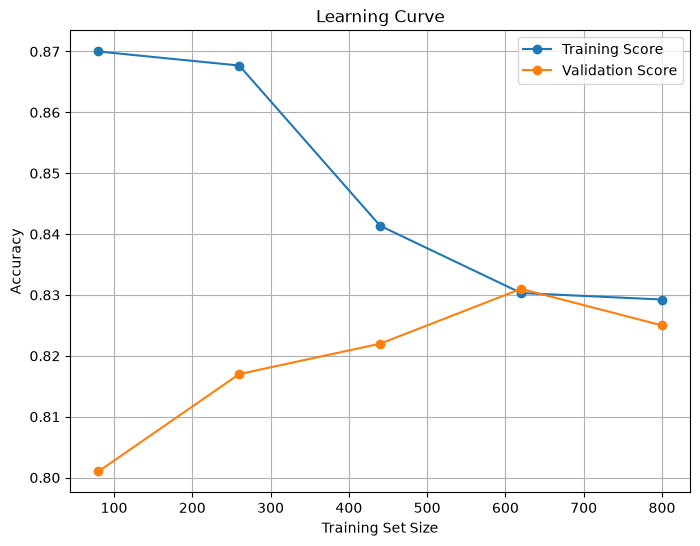

In [15]:
plt.figure(figsize=(8, 6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Score"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation Score"
)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid()

plt.show()

### Learning Curve Interpretation

If the training and validation scores are both low, the model may be underfitting.

If the training score is high but the validation score remains much lower, the model may be overfitting.

If both scores are high and relatively close, the model generally has good generalization.

## 14. MLflow Experiment Tracking

MLflow is used to track the model evaluation experiment.

We log the model type, cross-validation method, and evaluation metrics so that the experiment results can be recorded and compared.

In [16]:
mlflow.set_experiment("W4D1_Model_Evaluation")

with mlflow.start_run():

    mlflow.log_param("model", "Logistic Regression")
    mlflow.log_param("cross_validation", "Stratified K-Fold")
    mlflow.log_param("n_splits", 5)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", auc)

    mlflow.log_metric(
        "mean_stratified_cv_accuracy",
        stratified_scores.mean()
    )

    mlflow.log_metric(
        "std_stratified_cv_accuracy",
        stratified_scores.std()
    )

    print("MLflow experiment tracking completed successfully.")

2026/09/07 20:44:32 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/07 20:44:33 INFO mlflow.store.db.utils: Updating database tables
2026/09/07 20:44:41 INFO mlflow.tracking.fluent: Experiment with name 'W4D1_Model_Evaluation' does not exist. Creating a new experiment.


MLflow experiment tracking completed successfully.


## 15. Final Evaluation Summary

The classification model was evaluated using multiple metrics.

Accuracy measures overall correctness, while Precision focuses on the correctness of positive predictions. Recall measures how many actual positive cases were identified. F1 Score balances Precision and Recall. ROC-AUC measures the model's ability to distinguish between the two classes.

Cross-validation was used to check model generalization, and MLflow was used to track the experiment results.

In [17]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Mean Stratified CV Accuracy"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        auc,
        stratified_scores.mean()
    ]
})

print(results.to_string(index=False))

                     Metric    Score
                   Accuracy 0.820000
                  Precision 0.790909
                     Recall 0.870000
                   F1 Score 0.828571
                    ROC-AUC 0.879700
Mean Stratified CV Accuracy 0.825000


## 16. Final Conclusion

The Logistic Regression model was evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

K-Fold and Stratified K-Fold Cross-Validation were used to evaluate model stability and generalization.

The learning curve was used to identify possible overfitting or underfitting.

MLflow was used to track the evaluation metrics and experiment configuration.

Overall, combining multiple evaluation metrics with cross-validation provides a more reliable assessment of classification model performance.